In [1]:
import os
os.environ["WORLD_SIZE"] = "1"
os.environ["RANK"] = "0"
os.environ["LOCAL_RANK"] = "0"
os.environ["MASTER_ADDR"] = "localhost"
os.environ["MASTER_PORT"] = "12355"

# Adding a New Dataset to the Benchmarking Workflow

The PhysicsNeMo benchmarking workflow uses **dataset adapters** to decouple datasets from models and metrics. When you have a new CFD dataset with a different file layout or field naming convention, you write an adapter to map it into the canonical schema — and then every registered model and metric just works.

In this notebook we walk through the process using the [DrivAerStar](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/UXVXQV) dataset as an example. DrivAerStar is an industrial-grade automotive CFD dataset hosted on Harvard Dataverse, with a substantially different format from the built-in DrivAerML adapter. We will download a subset, write an adapter, and run GeoTransolver and Transolver inference and benchmarking end to end.

## Download the Data

DrivAerStar is hosted on Harvard Dataverse. The cell below downloads a single zip (`vtk_N_0.zip`) containing 50 surface mesh VTK files from the notchback (class N) vehicle category. If the data is already present it skips the download.

In [2]:
import urllib.request
import json
import shutil
import zipfile
import glob
import os

PERSISTENT_ID = "doi:10.7910/DVN/UXVXQV"
VERSION = "5.2"
BASE_URL = "https://dataverse.harvard.edu/api"
TARGET_FILE = "vtk_N_0.zip"
DATA_DIR = "drivaerstar_data"

# Dataverse's WAF returns 403 to the default ``Python-urllib/X.Y`` UA, so set a realistic one.
USER_AGENT = "Mozilla/5.0 (compatible; physicsnemo-cfd-notebook)"
PAGE_SIZE = 500

def _open(url):
    return urllib.request.urlopen(
        urllib.request.Request(url, headers={"User-Agent": USER_AGENT})
    )

def _find_file_id(target):
    """Paginate Dataverse listing until ``target`` is found (~7.8k files in v5.2)."""
    offset = 0
    while True:
        url = (
            f"{BASE_URL}/datasets/:persistentId/versions/{VERSION}/files"
            f"?persistentId={PERSISTENT_ID}&limit={PAGE_SIZE}&offset={offset}"
        )
        with _open(url) as resp:
            page = json.loads(resp.read()).get("data", [])
        if not page:
            raise FileNotFoundError(f"{target!r} not found in Dataverse listing.")
        for f in page:
            if f["dataFile"]["filename"] == target:
                return f["dataFile"]["id"]
        if len(page) < PAGE_SIZE:
            raise FileNotFoundError(f"{target!r} not found in Dataverse listing.")
        offset += PAGE_SIZE

os.makedirs(DATA_DIR, exist_ok=True)

existing_vtks = glob.glob(os.path.join(DATA_DIR, "*.vtk"))
if existing_vtks:
    print(f"{DATA_DIR}/ already has {len(existing_vtks)} VTK files. Skipping download.")
else:
    zip_path = TARGET_FILE if os.path.exists(TARGET_FILE) else os.path.join(DATA_DIR, TARGET_FILE)

    if not os.path.exists(zip_path):
        print(f"Locating {TARGET_FILE} in Dataverse listing...")
        file_id = _find_file_id(TARGET_FILE)
        print(f"Downloading {TARGET_FILE} (file_id={file_id})...")
        with _open(f"{BASE_URL}/access/datafile/{file_id}") as resp, open(zip_path, "wb") as out:
            shutil.copyfileobj(resp, out)
        print("Download complete.")

    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_DIR)
    print(f"Extracted {len(glob.glob(os.path.join(DATA_DIR, '*.vtk')))} VTK files to {DATA_DIR}/")


Locating vtk_N_0.zip in Dataverse listing...


Download complete.
Extracting drivaerstar_data/vtk_N_0.zip...


Extracted 50 VTK files to drivaerstar_data/


## Exploring the Data

Let's read one of the VTK files and examine its structure to understand what we're working with.

In [3]:
import glob
import pyvista as pv

vtk_files = sorted(glob.glob(f"{DATA_DIR}/*.vtk"))
print(f"Found {len(vtk_files)} VTK files")
print(f"First few: {[os.path.basename(f) for f in vtk_files[:5]]}")

sample = pv.read(vtk_files[0])
print(f"\nMesh type: {type(sample).__name__}")
print(f"Points: {sample.n_points:,}  Cells: {sample.n_cells:,}")
print(f"Cell arrays: {list(sample.cell_data.keys())}")
print(f"Point arrays: {list(sample.point_data.keys())}")

Found 50 VTK files
First few: ['00003.vtk', '00004.vtk', '00006.vtk', '00007.vtk', '00011.vtk']

Mesh type: PolyData
Points: 376,991  Cells: 338,342
Cell arrays: ['Pressure', 'Normals', 'Area', 'WallShearStressi', 'WallShearStressj', 'WallShearStressk']
Point arrays: ['Normals']


We can already see several differences from DrivAerML. The table below summarizes them — our adapter will need to handle each one.

| Aspect | DrivAerML | DrivAerStar |
| ------ | --------- | ----------- |
| File format | `.vtp` (VTK PolyData XML) | `.vtk` (legacy VTK PolyData) |
| Directory layout | `run_<id>/boundary_<id>.vtp` | Flat: `<id>.vtk` |
| Pressure field | `pMeanTrim` (cell) | `Pressure` (cell) |
| Wall shear stress | `wallShearStressMeanTrim` (cell, 3-component vector) | Three separate scalars: `WallShearStressi`, `WallShearStressj`, `WallShearStressk` (opposite sign convention) |
| Normals / Area | Not present (computed from mesh topology) | Explicit cell arrays — must be removed to match DrivAerML |
| STL files | Separate `drivaer_<id>.stl` per run | Not included — the surface mesh itself is the geometry |

## Writing the Dataset Adapter

A dataset adapter subclasses `DatasetAdapter` and implements two methods: `list_cases` (return available case IDs) and `load_case` (load a single case into the canonical `CanonicalCase` schema with ground-truth fields mapped to the standard keys `pressure` and `shear_stress`).

For DrivAerStar, the adapter also needs to handle the format conversions we identified above. We do this transparently inside `load_case` by preparing a VTP and STL on first access and caching them for subsequent runs.

In [4]:
import numpy as np
from pathlib import Path
import pyvista as pv

from physicsnemo.cfd.evaluation.datasets.adapter_registry import DatasetAdapter, register_adapter
from physicsnemo.cfd.evaluation.datasets.schema import CanonicalCase


class DrivAerStarAdapter(DatasetAdapter):
    """Adapter for DrivAerStar surface VTK files in a flat directory.
    
    DrivAerStar uses legacy .vtk format with field names that differ from
    DrivAerML (e.g. ``Pressure`` instead of ``pMeanTrim``, and three separate
    WSS scalars instead of a single vector).  The adapter transparently:
    
    1. Converts .vtk to .vtp (XML PolyData) for model wrapper compatibility
    2. Combines the 3 WSS scalars into a single vector
    3. Renames fields to DrivAerML conventions
    4. Generates a triangulated STL for geometry encoding
    """

    def __init__(self, root: str, **kwargs):
        self._root = Path(root)
        self._prepared_dir = self._root / "_prepared"
        self._prepared_dir.mkdir(exist_ok=True)

    @classmethod
    def inference_domain(cls):
        return "surface"

    @classmethod
    def inference_domain_from_kwargs(cls, kwargs=None):
        return "surface"

    def list_cases(self, split=None):
        vtk_files = sorted(self._root.glob("*.vtk"))
        return [f.stem for f in vtk_files]

    def _prepare_case(self, case_id: str) -> str:
        """Convert VTK to VTP with DrivAerML-compatible field names and create STL."""
        vtk_path = self._root / f"{case_id}.vtk"
        vtp_path = self._prepared_dir / f"{case_id}.vtp"
        tag = int(case_id)
        stl_path = self._prepared_dir / f"drivaer_{tag}.stl"

        if not vtp_path.exists():
            mesh = pv.read(str(vtk_path)).extract_surface()

            # Rename pressure
            if "Pressure" in mesh.cell_data:
                mesh.cell_data["pMeanTrim"] = mesh.cell_data.pop("Pressure")

            # Combine 3 WSS scalars into a single (N, 3) vector.
            # DrivAerStar WSS sign convention is flipped relative to DrivAerML — negate to align.
            wss_keys = ["WallShearStressi", "WallShearStressj", "WallShearStressk"]
            if all(k in mesh.cell_data for k in wss_keys):
                wss = -np.stack([mesh.cell_data.pop(k) for k in wss_keys], axis=1).astype(np.float32)
                mesh.cell_data["wallShearStressMeanTrim"] = wss

            # DrivAerML has no explicit Normals or Area arrays — the mesh topology
            # encodes face orientation. Remove these to avoid interfering with
            # rendering (ParaView) and force computation (compute_drag_and_lift).
            for key in ["Normals", "Area"]:
                if key in mesh.cell_data:
                    del mesh.cell_data[key]
            if "Normals" in mesh.point_data:
                del mesh.point_data["Normals"]

            mesh.save(str(vtp_path))

        if not stl_path.exists():
            mesh = pv.read(str(vtk_path)).extract_surface()
            mesh.triangulate().save(str(stl_path))

        return str(vtp_path)

    def load_case(self, case_id: str) -> CanonicalCase:
        vtk_path = self._root / f"{case_id}.vtk"
        if not vtk_path.exists():
            raise FileNotFoundError(f"VTK not found: {vtk_path}")

        vtp_path = self._prepare_case(case_id)
        mesh = pv.read(vtp_path)

        gt = {}
        if "pMeanTrim" in mesh.cell_data:
            gt["pressure"] = np.asarray(mesh.cell_data["pMeanTrim"], dtype=np.float32)
        if "wallShearStressMeanTrim" in mesh.cell_data:
            gt["shear_stress"] = np.asarray(mesh.cell_data["wallShearStressMeanTrim"], dtype=np.float32)

        return CanonicalCase(
            case_id=case_id,
            mesh_path=vtp_path,
            mesh_type="cell",
            ground_truth=gt if gt else None,
            inference_domain="surface",
        )


# Register the adapter so the benchmarking engine can find it by name
register_adapter("drivaerstar", DrivAerStarAdapter)
print("Registered 'drivaerstar' adapter.")

Registered 'drivaerstar' adapter.


We can verify the adapter works by listing cases and loading one. The ground-truth dictionary should contain `pressure` (scalar) and `shear_stress` (3-component vector) in the canonical format.

In [5]:
adapter = DrivAerStarAdapter(root=DATA_DIR)
cases = adapter.list_cases()
print(f"Found {len(cases)} cases: {cases[:5]}...")

case = adapter.load_case(cases[0])
print(f"\nCase: {case.case_id}")
print(f"Mesh path: {case.mesh_path}")
print(f"Mesh type: {case.mesh_type}")
print(f"Inference domain: {case.inference_domain}")
print(f"GT keys: {list(case.ground_truth.keys())}")
print(f"Pressure shape: {case.ground_truth['pressure'].shape}")
print(f"Shear stress shape: {case.ground_truth['shear_stress'].shape}")

Found 50 cases: ['00003', '00004', '00006', '00007', '00011']...


/tmp/ipykernel_83546/170339151.py:47: PyVistaFutureWarning: The default value of `algorithm` for the filter
`PolyData.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  mesh = pv.read(str(vtk_path)).extract_surface()


/tmp/ipykernel_83546/170339151.py:72: PyVistaFutureWarning: The default value of `algorithm` for the filter
`PolyData.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  mesh = pv.read(str(vtk_path)).extract_surface()



Case: 00003
Mesh path: drivaerstar_data/_prepared/00003.vtp
Mesh type: cell
Inference domain: surface
GT keys: ['pressure', 'shear_stress']
Pressure shape: (338342,)
Shear stress shape: (338342, 3)


## Preparing Cases for Inference

When `load_case` is called, the adapter's `_prepare_case` method transparently handles all format conversion: converting `.vtk` to `.vtp`, renaming fields to DrivAerML conventions, combining the three WSS scalars into a single vector, removing explicit normals/area arrays, and creating a triangulated STL for geometry encoding. Prepared files are cached in a `_prepared/` subdirectory so subsequent runs skip the conversion.

Let's prepare a couple of cases and verify they're ready.

In [6]:
INFERENCE_CASES = cases[:2]

for case_id in INFERENCE_CASES:
    case = adapter.load_case(case_id)
    prepared_dir = os.path.join(DATA_DIR, "_prepared")
    print(f"Case {case_id}:")
    print(f"  VTP: {case.mesh_path}")
    print(f"  STL: {os.path.join(prepared_dir, f'drivaer_{int(case_id)}.stl')}")
    print(f"  GT keys: {list(case.ground_truth.keys())}")

Case 00003:
  VTP: drivaerstar_data/_prepared/00003.vtp
  STL: drivaerstar_data/_prepared/drivaer_3.stl
  GT keys: ['pressure', 'shear_stress']


/tmp/ipykernel_83546/170339151.py:47: PyVistaFutureWarning: The default value of `algorithm` for the filter
`PolyData.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  mesh = pv.read(str(vtk_path)).extract_surface()


/tmp/ipykernel_83546/170339151.py:72: PyVistaFutureWarning: The default value of `algorithm` for the filter
`PolyData.extract_surface` will change in the future. It currently defaults to
`'dataset_surface'`, but will change to `None`. Explicitly set the `algorithm` keyword to
silence this warning.
  mesh = pv.read(str(vtk_path)).extract_surface()


Case 00004:
  VTP: drivaerstar_data/_prepared/00004.vtp
  STL: drivaerstar_data/_prepared/drivaer_4.stl
  GT keys: ['pressure', 'shear_stress']


## Running Model Inference

Since the adapter produces standard `CanonicalCase` objects, any registered model wrapper works without modification. Below we load both GeoTransolver and Transolver and run inference on the same DrivAerStar cases.

In [7]:
import time
from physicsnemo.cfd.evaluation.assets import resolve_model_assets
from physicsnemo.cfd.evaluation.config import ModelConfig
from physicsnemo.cfd.evaluation.models import get_model_wrapper

# Resolve checkpoint + stats from Hugging Face via ``builtin_packages``.
# Set ``checkpoint=...`` / ``stats_path=...`` on ``ModelConfig`` to override with local paths.
loaded = {}
for model_name in ["geotransolver_surface", "transolver_surface"]:
    cfg = ModelConfig(name=model_name, checkpoint="", stats_path="")
    wrapper_cls = get_model_wrapper(model_name)
    ck_path, st_path, _aid, load_kw = resolve_model_assets(cfg, wrapper_cls)

    wrapper = wrapper_cls()
    wrapper.load(
        checkpoint_path=ck_path,
        stats_path=st_path,
        device="cuda:0",
        batch_resolution=60000,
        geometry_sampling=300000,
        **load_kw,
    )
    loaded[model_name] = wrapper
    print(f"{model_name}: loaded.")

geotransolver = loaded["geotransolver_surface"]
transolver = loaded["transolver_surface"]


/localhome/local-ktangsali/development_workspace/physicsnemo-cfd-api-docs/physicsnemo-cfd/physicsnemo/cfd/evaluation/models/wrappers/geotransolver/wrapper.py:66: ExperimentalFeatureWarning: You are importing from 'physicsnemo.experimental'. The APIs in this namespace are experimental, under active development, and may change without notice. Expect possible back-compatibility breaking changes and only partial test coverage.
  from physicsnemo.experimental.models.geotransolver import GeoTransolver


[inference:geotransolver] Loading surface normalization from /localhome/local-ktangsali/.cache/physicsnemo-cfd/models/packages/geotransolver_surface/models--nvidia--geotransolver_drivaerml/snapshots/ddda24db315f6fca8d67c76f3da511ea4d9da86e/geotransolver_drivaerml_surface_checkpoint/global_stats.json


Could not find valid checkpoint file, skipping load


geotransolver_surface: loaded.


config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

...

[inference:transolver] Loading surface normalization from /localhome/local-ktangsali/.cache/physicsnemo-cfd/models/packages/transolver_surface/models--nvidia--transolver_drivaerml/snapshots/96477aeb86d24c26ccf0797bca1b3851268017d0/transolver_drivaerml_surface_checkpoint/global_stats.json


[inference:transolver] Loading checkpoint from /localhome/local-ktangsali/.cache/physicsnemo-cfd/models/packages/transolver_surface/models--nvidia--transolver_drivaerml/snapshots/96477aeb86d24c26ccf0797bca1b3851268017d0/transolver_drivaerml_surface_checkpoint


Could not find valid checkpoint file, skipping load


[inference:transolver] Checkpoint loaded; model ready for inference.


transolver_surface: loaded.


In [8]:
import pyvista as pv
case = adapter.load_case(INFERENCE_CASES[0])
vis_mesh = pv.read(case.mesh_path)
print(f"Running inference on case {INFERENCE_CASES[0]}...")

for name, wrapper in [("GeoTransolver", geotransolver), ("Transolver", transolver)]:
    start = time.time()
    model_input = wrapper.prepare_inputs(case)
    raw_output = wrapper.predict(model_input)
    predictions = wrapper.decode_outputs(raw_output, case)
    elapsed = time.time() - start
    print(f"\n  {name}: inference took {elapsed:.1f}s")
    for k, v in predictions.items():
        print(f"    {k}: shape={v.shape}, range=[{v.min():.4f}, {v.max():.4f}]")

    vis_mesh.cell_data[f"pMeanTrimPred_{name}"] = predictions["pressure"]
    vis_mesh.cell_data[f"wallShearStressMeanTrimPred_{name}"] = predictions["shear_stress"]

print(f"\nMesh has GT + predictions from both models: {list(vis_mesh.cell_data.keys())}")

os.makedirs("drivaerstar_benchmark_results", exist_ok=True)
vis_mesh.save("drivaerstar_benchmark_results/predictions_comparison.vtp")
print(f"Saved combined mesh to drivaerstar_benchmark_results/predictions_comparison.vtp")

Running inference on case 00003...
[inference:geotransolver] Reading case inputs (case 00003): mesh drivaerstar_data/_prepared/00003.vtp, run dir drivaerstar_data/_prepared


[inference:geotransolver] Running forward pass (predicting fields)…


[inference:geotransolver] Decoding outputs (pressure + WSS to numpy)…



  GeoTransolver: inference took 8.6s
    pressure: shape=(338342,), range=[-1619.4648, 654.4575]
    shear_stress: shape=(338342, 3), range=[-12.9242, 10.3043]
[inference:transolver] Reading case inputs (case 00003): mesh drivaerstar_data/_prepared/00003.vtp, run dir drivaerstar_data/_prepared


[inference:transolver] Running forward pass (predicting fields)…


[inference:transolver] Decoding outputs (pressure + WSS to numpy)…



  Transolver: inference took 5.1s
    pressure: shape=(338342,), range=[-1459.6375, 672.1802]
    shear_stress: shape=(338342, 3), range=[-10.9006, 7.8712]

Mesh has GT + predictions from both models: ['vtkOriginalCellIds', 'pMeanTrim', 'wallShearStressMeanTrim', 'pMeanTrimPred_GeoTransolver', 'wallShearStressMeanTrimPred_GeoTransolver', 'pMeanTrimPred_Transolver', 'wallShearStressMeanTrimPred_Transolver']


Saved combined mesh to drivaerstar_benchmark_results/predictions_comparison.vtp


## Running the Full Benchmark

With the adapter registered, we can use the full benchmarking engine. The configuration below runs both models in matrix mode against our DrivAerStar cases, computing L2 errors, area-weighted L2, and drag/lift metrics.

In [9]:
from physicsnemo.cfd.evaluation.config import Config
from physicsnemo.cfd.evaluation.benchmarks.engine import run_benchmark

# ``checkpoint`` / ``stats_path`` are omitted: the engine resolves them from
# ``BUILTIN_MODEL_PACKAGE_ROOTS`` (Hugging Face). Set them to override with local paths.
config = Config.from_dict({
    "run": {
        "device": "cuda:0",
        "output_dir": "drivaerstar_benchmark_results",
        "save_inference_mesh": False,
        "metrics_cache": {"enabled": False},
    },
    "benchmark": {
        "mode": "matrix",
        "models": [
            {
                "name": "geotransolver_surface",
                "inference_domain": "surface",
                "kwargs": {"batch_resolution": 60000, "geometry_sampling": 300000},
            },
            {
                "name": "transolver_surface",
                "inference_domain": "surface",
                "kwargs": {"batch_resolution": 60000, "geometry_sampling": 300000},
            },
        ],
        "datasets": [
            {
                "name": "drivaerstar",
                "root": DATA_DIR,
                "case_ids": INFERENCE_CASES,
            },
        ],
        "reproducibility": {"log_env": False, "save_artifacts": True},
    },
    "output": {
        "mesh_field_names": {
            "pressure": "pMeanTrimPred",
            "shear_stress": "wallShearStressMeanTrimPred",
        },
        "ground_truth_mesh_field_names": {
            "pressure": "pMeanTrim",
            "shear_stress": "wallShearStressMeanTrim",
        },
    },
    "metrics": [
        "l2_pressure",
        "l2_shear_stress",
        "l2_pressure_area_weighted",
        "drag",
        "lift",
    ],
    "reports": {"enabled": False},
})

print("Config created. Running matrix benchmark (GeoTransolver + Transolver)...")
results = run_benchmark(config)
print("Benchmark complete.")


Config created. Running matrix benchmark (GeoTransolver + Transolver)...
[dataset:benchmark] Distributed: rank 0/1 (no case sharding).


[dataset:drivaerstar] Listing cases under root 'drivaerstar_data'…


[dataset:drivaerstar] Loading 2 case(s) from root 'drivaerstar_data' (model 'geotransolver_surface')…


[inference:geotransolver] Loading surface normalization from /localhome/local-ktangsali/.cache/physicsnemo-cfd/models/packages/geotransolver_surface/models--nvidia--geotransolver_drivaerml/snapshots/ddda24db315f6fca8d67c76f3da511ea4d9da86e/geotransolver_drivaerml_surface_checkpoint/global_stats.json


Could not find valid checkpoint file, skipping load


...

[dataset:benchmark] Writing benchmark reports to drivaerstar_benchmark_results (formats: json, csv, html)…


[dataset:benchmark] Writing drivaerstar_benchmark_results/benchmark_results.json…


[dataset:benchmark] Writing drivaerstar_benchmark_results/benchmark_results.csv…


[dataset:benchmark] Writing drivaerstar_benchmark_results/benchmark_results.html…


Benchmark complete.


## Inspecting Results

The benchmark engine writes JSON, CSV, and HTML reports. Let's look at the aggregate and per-case metrics.

In [10]:
import json

for run in results:
    print(f"Model: {run['model']}  Dataset: {run['dataset']}")
    print(f"Cases: {run['cases']}")
    print(f"\nAggregate metrics (mean over cases):")
    for metric, value in run["metrics"].items():
        print(f"  {metric}: {value:.6f}")
    print(f"\nPer-case metrics:")
    for row in run["per_case"]:
        print(f"  {row['case_id']}:")
        for k, v in row["metrics"].items():
            print(f"    {k}: {v:.6f}")

Model: geotransolver_surface  Dataset: drivaerstar
Cases: ['00003', '00004']

Aggregate metrics (mean over cases):
  l2_pressure: 0.671118
  l2_shear_stress_wallShearStressMeanTrim_x_l2_error: 0.770670
  l2_shear_stress_wallShearStressMeanTrim_y_l2_error: 0.916382
  l2_shear_stress_wallShearStressMeanTrim_z_l2_error: 0.952979
  l2_pressure_area_weighted: 0.616933
  drag_error: 0.697032
  drag_true: 567.510562
  drag_pred: 171.527034
  lift_error: 0.962973
  lift_true: 312.986585
  lift_pred: 29.121614

Per-case metrics:
  00003:
    l2_pressure: 0.633680
    l2_shear_stress_wallShearStressMeanTrim_x_l2_error: 0.770515
    l2_shear_stress_wallShearStressMeanTrim_y_l2_error: 0.900722
    l2_shear_stress_wallShearStressMeanTrim_z_l2_error: 0.955194
    l2_pressure_area_weighted: 0.590191
    drag_error: 0.689649
    drag_true: 511.913775
    drag_pred: 158.873108
    lift_error: 0.648388
    lift_true: 368.719453
    lift_pred: 129.646283
  00004:
    l2_pressure: 0.708556
    l2_shear_st

In [11]:
# The benchmark also wrote JSON/CSV results
results_dir = "drivaerstar_benchmark_results"
for f in ["benchmark_results.json", "benchmark_results.csv"]:
    path = os.path.join(results_dir, f)
    if os.path.exists(path):
        print(f"\n--- {f} ---")
        with open(path) as fh:
            print(fh.read()[:2000])


--- benchmark_results.json ---
[
  {
    "model": "geotransolver_surface",
    "dataset": "drivaerstar",
    "cases": [
      "00003",
      "00004"
    ],
    "metrics": {
      "l2_pressure": 0.6711179411957806,
      "l2_shear_stress_wallShearStressMeanTrim_x_l2_error": 0.7706701087657012,
      "l2_shear_stress_wallShearStressMeanTrim_y_l2_error": 0.9163819235689576,
      "l2_shear_stress_wallShearStressMeanTrim_z_l2_error": 0.9529786238475322,
      "l2_pressure_area_weighted": 0.6169331591281215,
      "drag_error": 0.6970320287864471,
      "drag_true": 567.5105623429952,
      "drag_pred": 171.52703409603708,
      "lift_error": 0.9629733086290728,
      "lift_true": 312.98658475660875,
      "lift_pred": 29.121614224533126
    },
    "per_case": [
      {
        "case_id": "00003",
        "metrics": {
          "l2_pressure": 0.6336796102076642,
          "l2_shear_stress_wallShearStressMeanTrim_x_l2_error": 0.7705154324710858,
          "l2_shear_stress_wallShearStressMea

Numerical metrics give an aggregate picture, but visualizing the fields reveals where the models agree and disagree with the ground truth. Below we plot the pressure field for both models alongside the reference solution.

---
**NOTE**

The L2 errors above are expected to be higher than typical in-distribution results. The models (GeoTransolver, Transolver) were trained on the DrivAerML dataset, which was generated using Hybrid RANS-LES (HRLES) simulations. DrivAerStar, on the other hand, is a steady-state RANS dataset. The differences in turbulence modeling between the two simulation methodologies lead to systematic discrepancies in the flow fields — particularly in turbulent quantities such as wall shear stress. This cross-methodology gap is inherent and does not necessarily reflect the model's predictive capability on in-distribution data.

---

2026-05-09 23:03:17.695 (  83.792s) [    7F1965F11080]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


Saved drivaerstar_benchmark_results/field_comparison_GeoTransolver.png


Saved drivaerstar_benchmark_results/field_comparison_Transolver.png

--- GeoTransolver ---


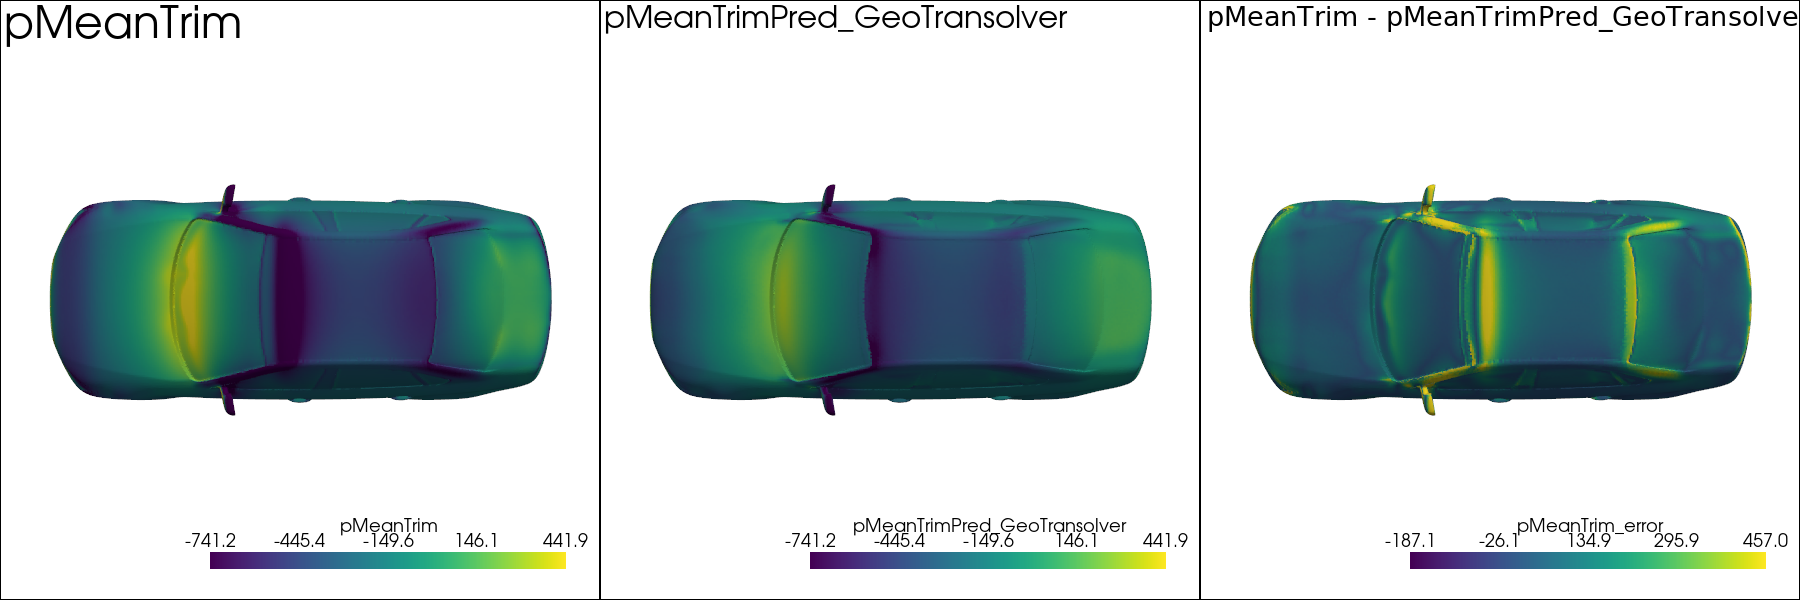


--- Transolver ---


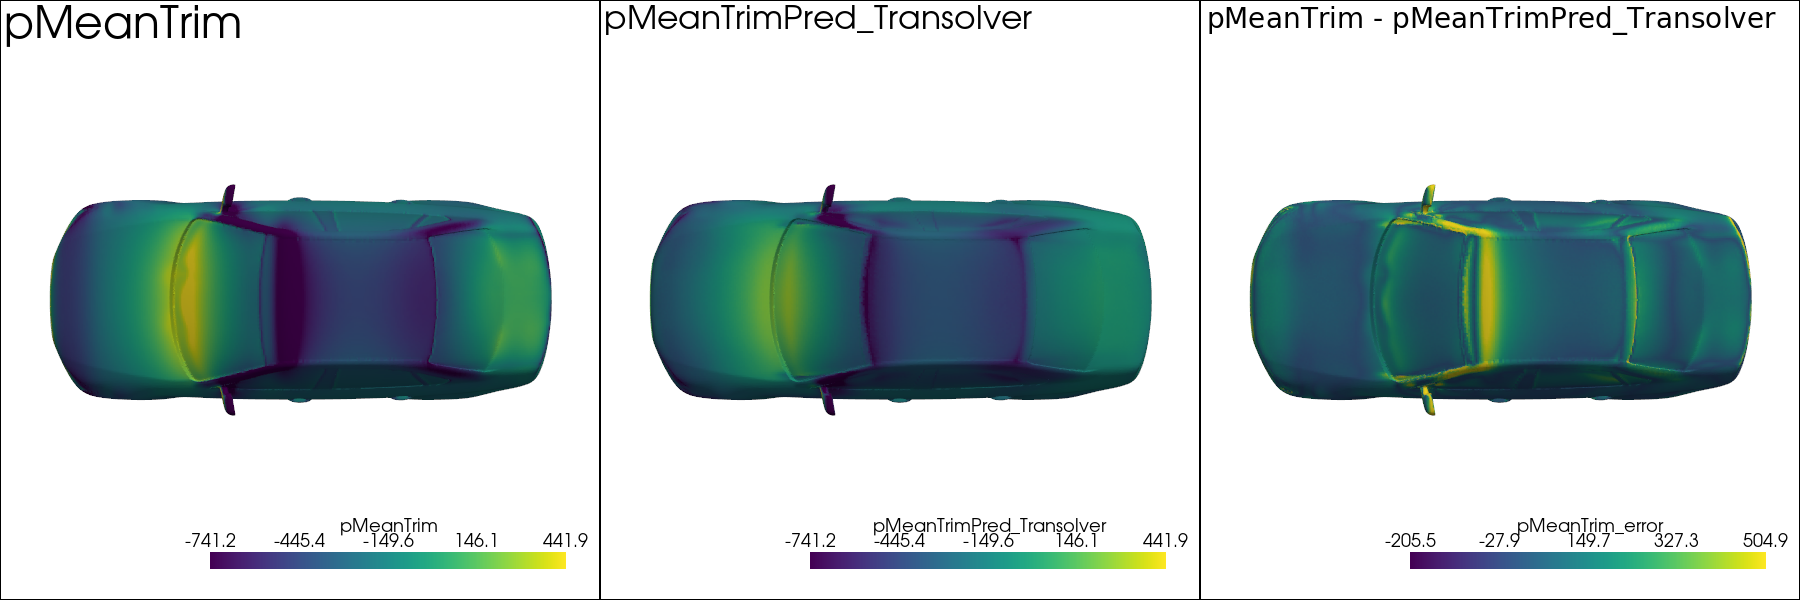

In [12]:
import pyvista as pv
from physicsnemo.cfd.postprocessing_tools.visualization.utils import plot_field_comparisons
from IPython.display import Image

_xvfb = getattr(pv, "start_xvfb", None)
if _xvfb is not None:
    _xvfb()
else:
    pv.OFF_SCREEN = True

for name in ["GeoTransolver", "Transolver"]:
    plotter = plot_field_comparisons(
        vis_mesh,
        true_fields=["pMeanTrim"],
        pred_fields=[f"pMeanTrimPred_{name}"],
        view="xy",
        dtype="cell",
        window_size=[1800, 600],
    )
    out_path = f"drivaerstar_benchmark_results/field_comparison_{name}.png"
    os.makedirs("drivaerstar_benchmark_results", exist_ok=True)
    plotter.screenshot(out_path)
    plotter.close()
    print(f"Saved {out_path}")

print("\n--- GeoTransolver ---")
display(Image(filename="drivaerstar_benchmark_results/field_comparison_GeoTransolver.png"))
print("\n--- Transolver ---")
display(Image(filename="drivaerstar_benchmark_results/field_comparison_Transolver.png"))

## Next Steps

That completes the dataset adapter tutorial. We downloaded DrivAerStar data, wrote an adapter to handle its format differences (legacy VTK, separate WSS scalars, missing STLs, explicit normals), ran GeoTransolver and Transolver inference, and evaluated both models with the benchmarking engine.

The key insight is that all the dataset-specific complexity lives inside the adapter. Once it produces standard `CanonicalCase` objects, every model wrapper and metric works without modification.

Note that the field renames, sign flips, and format conversions we performed were necessary because the model checkpoints were trained on DrivAerML, which follows specific naming and sign conventions. The adapter bridges the gap between the new dataset's conventions and the training data's conventions. If a model were trained directly on DrivAerStar data, these transformations would not be needed — the adapter would simply expose the native fields as-is.

To make the adapter permanent, save the class to `physicsnemo/cfd/evaluation/datasets/adapters/drivaerstar.py` and register it in `adapters/__init__.py`:

```python
from physicsnemo.cfd.evaluation.datasets.adapters.drivaerstar import DrivAerStarAdapter
register_adapter("drivaerstar", DrivAerStarAdapter)
```

Then use `dataset.name: drivaerstar` in any YAML config. For other datasets, the same pattern applies — explore the data, identify the differences from the canonical schema, and write an adapter to bridge them.